# SkyAware Flight Delay Prediction — Notebook 3: Dataset Split & S3 Archival

**AAI-540 MLOps | Group 4**

This notebook applies a **temporal train/validation/test split** to prevent data leakage:
- **Train**: 2010–2018 (historical baseline)
- **Validation**: 2019–2021 (includes COVID disruption)
- **Test**: 2022–2025 (post-pandemic recovery)

Splits are archived to `s3://skyaware-processed-data/splits/`.

## 1. Setup & Imports

In [1]:
import boto3
import pandas as pd
import numpy as np
import os
import pickle
import io
import warnings
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
warnings.filterwarnings('ignore')

import sagemaker
from sagemaker import get_execution_role
from sklearn.preprocessing import LabelEncoder
from sklearn.utils.class_weight import compute_class_weight

region = boto3.Session().region_name
role = get_execution_role()
s3_client = boto3.client('s3', region_name=region)

PROCESSED_BUCKET = 'skyaware-processed-data'
RAW_BUCKET = 'skyaware-raw-data'

print(f'Region: {region}')
print(f'Processed bucket: {PROCESSED_BUCKET}')

sagemaker.config INFO - Not applying SDK defaults from location: /etc/xdg/sagemaker/config.yaml


sagemaker.config INFO - Not applying SDK defaults from location: /home/sagemaker-user/.config/sagemaker/config.yaml


Region: us-east-1
Processed bucket: skyaware-processed-data


In [2]:
# Create S3 buckets if they don't exist
def create_bucket_if_missing(bucket_name):
    try:
        s3_client.head_bucket(Bucket=bucket_name)
        print(f'Bucket exists: s3://{bucket_name}')
    except Exception as e:
        error_code = e.response['Error']['Code'] if hasattr(e, 'response') else ''
        if error_code in ('404', 'NoSuchBucket'):
            try:
                if region == 'us-east-1':
                    s3_client.create_bucket(Bucket=bucket_name)
                else:
                    s3_client.create_bucket(
                        Bucket=bucket_name,
                        CreateBucketConfiguration={'LocationConstraint': region}
                    )
                print(f'Created bucket: s3://{bucket_name}')
            except Exception as create_err:
                print(f'Could not create {bucket_name}: {create_err}')
        else:
            print(f'Bucket check error for {bucket_name}: {e}')

for bucket in [RAW_BUCKET, PROCESSED_BUCKET]:
    create_bucket_if_missing(bucket)

Bucket exists: s3://skyaware-raw-data
Bucket exists: s3://skyaware-processed-data


## 2. Load Engineered Features

In [3]:
# Option A: load from S3 (engineered features output of NB02)
def load_from_s3(bucket, key):
    try:
        obj = s3_client.get_object(Bucket=bucket, Key=key)
        return pd.read_csv(obj['Body'])
    except Exception as e:
        print(f'S3 load failed ({e}), trying fallback...')
        return None

df = load_from_s3(PROCESSED_BUCKET, 'interim/engineered_features.csv')

# Option B: fallback — re-derive all features from raw CSV
if df is None:
    raw_path = 'archive/Airline_Delay_Cause.csv'
    df = pd.read_csv(raw_path)
    df.columns = df.columns.str.strip()
    df = df[df['year'] >= 2010].copy()
    df = df[df['arr_flights'] > 0].copy()
    delay_cols = ['arr_del15','carrier_ct','weather_ct','nas_ct','security_ct',
                  'late_aircraft_ct','arr_cancelled','arr_diverted','arr_delay',
                  'carrier_delay','weather_delay','nas_delay','security_delay','late_aircraft_delay']
    df[delay_cols] = df[delay_cols].fillna(0)

    # Core rates
    df['delay_rate']  = df['arr_del15']       / df['arr_flights']
    df['cancel_rate'] = df['arr_cancelled']    / df['arr_flights']
    df['divert_rate'] = df['arr_diverted']     / df['arr_flights']

    # EDA-driven features
    df['is_covid_period']    = df['year'].isin([2020, 2021]).astype(int)
    df['late_aircraft_rate'] = df['late_aircraft_ct'] / df['arr_flights']
    df['carrier_delay_rate'] = df['carrier_ct']       / df['arr_flights']
    df['weather_delay_rate'] = df['weather_ct']        / df['arr_flights']
    df['nas_delay_rate']     = df['nas_ct']            / df['arr_flights']
    df['month_sin'] = np.sin(2 * np.pi * df['month'] / 12)
    df['month_cos'] = np.cos(2 * np.pi * df['month'] / 12)

    # Cause proportions and misc
    total_ct = df[['carrier_ct','weather_ct','nas_ct','security_ct','late_aircraft_ct']].sum(axis=1).clip(lower=1)
    df['carrier_delay_pct']  = df['carrier_ct']      / total_ct
    df['weather_delay_pct']  = df['weather_ct']       / total_ct
    df['nas_delay_pct']      = df['nas_ct']           / total_ct
    df['security_delay_pct'] = df['security_ct']      / total_ct
    df['late_aircraft_pct']  = df['late_aircraft_ct'] / total_ct
    df['avg_delay_per_flight'] = df['arr_delay'] / df['arr_flights'].clip(lower=1)
    df['quarter']        = ((df['month'] - 1) // 3 + 1).astype(int)
    df['is_winter']      = df['month'].isin([12, 1, 2]).astype(int)
    df['is_summer']      = df['month'].isin([6, 7, 8]).astype(int)
    df['is_peak_travel'] = df['month'].isin([6, 7, 8, 11, 12]).astype(int)

    # Rolling lag features
    df = df.sort_values(['carrier','year','month']).reset_index(drop=True)
    df['carrier_rolling_delay_3m']  = df.groupby('carrier')['delay_rate'].transform(lambda x: x.shift(1).rolling(3,  min_periods=1).mean())
    df['carrier_rolling_delay_12m'] = df.groupby('carrier')['delay_rate'].transform(lambda x: x.shift(1).rolling(12, min_periods=1).mean())
    df['late_aircraft_roll_3m']     = df.groupby('carrier')['late_aircraft_rate'].transform(lambda x: x.shift(1).rolling(3, min_periods=1).mean())
    df = df.sort_values(['airport','year','month']).reset_index(drop=True)
    df['airport_rolling_delay_3m']  = df.groupby('airport')['delay_rate'].transform(lambda x: x.shift(1).rolling(3, min_periods=1).mean())
    df = df.sort_values(['carrier','year','month']).reset_index(drop=True)
    df['carrier_yoy_delay_change']  = df.groupby(['carrier','month'])['delay_rate'].transform(lambda x: x.diff())
    for c in ['carrier_rolling_delay_3m','carrier_rolling_delay_12m','late_aircraft_roll_3m',
              'airport_rolling_delay_3m','carrier_yoy_delay_change']:
        df[c] = df[c].fillna(0)

    def assign_label(row):
        if row['cancel_rate'] > 0.05 or row['delay_rate'] > 0.40: return 3
        elif row['delay_rate'] > 0.25: return 2
        elif row['delay_rate'] > 0.15: return 1
        else: return 0
    df['delay_risk_label'] = df.apply(assign_label, axis=1)
    print('Derived all features from raw CSV.')

print(f'Dataset shape: {df.shape}')
print(f'Columns: {df.columns.tolist()}')
df.head(3)

Dataset shape: (281032, 33)
Columns: ['record_id', 'event_time', 'year', 'month', 'month_sin', 'month_cos', 'carrier', 'airport', 'arr_flights', 'delay_rate', 'cancel_rate', 'divert_rate', 'avg_delay_per_flight', 'late_aircraft_rate', 'carrier_delay_rate', 'weather_delay_rate', 'nas_delay_rate', 'carrier_delay_pct', 'weather_delay_pct', 'nas_delay_pct', 'security_delay_pct', 'late_aircraft_pct', 'quarter', 'is_winter', 'is_summer', 'is_peak_travel', 'is_covid_period', 'carrier_rolling_delay_3m', 'carrier_rolling_delay_12m', 'late_aircraft_roll_3m', 'airport_rolling_delay_3m', 'carrier_yoy_delay_change', 'delay_risk_label']


,record_id,event_time,year,month,month_sin,month_cos,carrier,airport,arr_flights,delay_rate,...,is_winter,is_summer,is_peak_travel,is_covid_period,carrier_rolling_delay_3m,carrier_rolling_delay_12m,late_aircraft_roll_3m,airport_rolling_delay_3m,carrier_yoy_delay_change,delay_risk_label
0,9E_ABE_2010_01,1.262304e+09,2010.0,1.0,0.5,0.866025,9E,ABE,65.0,0.246154,...,1.0,0.0,0.0,0.0,0.000000,0.000000,0.00000,0.0,0.000000,1.0
1,9E_AEX_2010_01,1.262304e+09,2010.0,1.0,0.5,0.866025,9E,AEX,60.0,0.283333,...,1.0,0.0,0.0,0.0,0.246154,0.246154,0.00000,0.0,0.037179,3.0
2,9E_ALB_2010_01,1.262304e+09,2010.0,1.0,0.5,0.866025,9E,ALB,81.0,0.419753,...,1.0,0.0,0.0,0.0,0.264744,0.264744,0.03175,0.0,0.136420,3.0


## 3. Data Preparation & Encoding

In [4]:
# Temporal split BEFORE encoding (fit encoders on train only)
train_raw = df[df['year'] <= 2018].copy()
val_raw   = df[(df['year'] >= 2019) & (df['year'] <= 2021)].copy()
test_raw  = df[df['year'] >= 2022].copy()

print(f'Train (2010-2018): {len(train_raw):,} rows')
print(f'Val   (2019-2021): {len(val_raw):,} rows')
print(f'Test  (2022-2025): {len(test_raw):,} rows')

# Verify no overlap
assert train_raw['year'].max() < val_raw['year'].min(), 'Train/Val year overlap!'
assert val_raw['year'].max() < test_raw['year'].min(), 'Val/Test year overlap!'
print('\nNo data leakage: year ranges are strictly separated.')

Train (2010-2018): 140,676 rows
Val   (2019-2021): 70,326 rows
Test  (2022-2025): 70,030 rows

No data leakage: year ranges are strictly separated.


In [5]:
# Encode categorical columns — fit ONLY on train
carrier_encoder = LabelEncoder()
airport_encoder = LabelEncoder()

carrier_encoder.fit(train_raw['carrier'])
airport_encoder.fit(train_raw['airport'])

def encode_split(split_df, carrier_enc, airport_enc):
    out = split_df.copy()
    # Handle unseen carriers/airports in val/test by mapping to -1 or mode
    known_carriers = set(carrier_enc.classes_)
    known_airports = set(airport_enc.classes_)
    out['carrier_unknown'] = (~out['carrier'].isin(known_carriers)).astype(int)
    out['airport_unknown'] = (~out['airport'].isin(known_airports)).astype(int)
    out.loc[~out['carrier'].isin(known_carriers), 'carrier'] = carrier_enc.classes_[0]
    out.loc[~out['airport'].isin(known_airports), 'airport'] = airport_enc.classes_[0]
    out['carrier_enc'] = carrier_enc.transform(out['carrier'])
    out['airport_enc'] = airport_enc.transform(out['airport'])
    return out

train_enc = encode_split(train_raw, carrier_encoder, airport_encoder)
val_enc   = encode_split(val_raw,   carrier_encoder, airport_encoder)
test_enc  = encode_split(test_raw,  carrier_encoder, airport_encoder)

print(f'Carrier classes: {len(carrier_encoder.classes_)}')
print(f'Airport classes: {len(airport_encoder.classes_)}')
print(f'Unseen carriers in val: {val_enc["carrier_unknown"].sum()}')
print(f'Unseen carriers in test: {test_enc["carrier_unknown"].sum()}')

Carrier classes: 32
Airport classes: 389
Unseen carriers in val: 0
Unseen carriers in test: 0


In [6]:
# Save encoders to S3 for use during inference
for enc, name in [(carrier_encoder, 'carrier_encoder'), (airport_encoder, 'airport_encoder')]:
    buf = io.BytesIO()
    pickle.dump(enc, buf)
    buf.seek(0)
    try:
        s3_client.put_object(Bucket=PROCESSED_BUCKET, Key=f'encoders/{name}.pkl', Body=buf.read())
        print(f'Saved s3://{PROCESSED_BUCKET}/encoders/{name}.pkl')
    except Exception as e:
        print(f'Encoder save note: {e}')

Saved s3://skyaware-processed-data/encoders/carrier_encoder.pkl
Saved s3://skyaware-processed-data/encoders/airport_encoder.pkl


In [7]:
# Define final feature columns — must match NB02 FEATURE_COLS (minus record_id, event_time)
FEATURE_COLS = [
    # Temporal
    'year', 'month', 'month_sin', 'month_cos',
    'quarter', 'is_winter', 'is_summer', 'is_peak_travel', 'is_covid_period',
    # Core rate features (delay_rate=0.67, cancel_rate=0.44 correlation with target)
    'arr_flights', 'delay_rate', 'cancel_rate', 'divert_rate', 'avg_delay_per_flight',
    # Rate-based cause features (per-flight; stronger signal than raw counts)
    'late_aircraft_rate', 'carrier_delay_rate', 'weather_delay_rate', 'nas_delay_rate',
    # Cause proportions
    'carrier_delay_pct', 'weather_delay_pct', 'nas_delay_pct',
    'security_delay_pct', 'late_aircraft_pct',
    # Rolling lag features
    'carrier_rolling_delay_3m', 'carrier_rolling_delay_12m', 'late_aircraft_roll_3m',
    'airport_rolling_delay_3m', 'carrier_yoy_delay_change',
    # Encoded categoricals
    'carrier_enc', 'airport_enc',
]
TARGET_COL = 'delay_risk_label'

# Subset to features + target only
def select_cols(split_df):
    available = [c for c in FEATURE_COLS if c in split_df.columns]
    missing = [c for c in FEATURE_COLS if c not in split_df.columns]
    if missing:
        print(f'  Warning: missing features (will be skipped): {missing}')
    out = split_df[available + [TARGET_COL]].copy()
    out.replace([np.inf, -np.inf], np.nan, inplace=True)
    out.fillna(0, inplace=True)
    return out

train_df = select_cols(train_enc)
val_df   = select_cols(val_enc)
test_df  = select_cols(test_enc)

print(f'Train shape: {train_df.shape}')
print(f'Val shape:   {val_df.shape}')
print(f'Test shape:  {test_df.shape}')
print(f'\nActive feature columns ({len([c for c in FEATURE_COLS if c in train_df.columns])}):')
print([c for c in FEATURE_COLS if c in train_df.columns])

Train shape: (140676, 31)
Val shape:   (70326, 31)
Test shape:  (70030, 31)

Active feature columns (30):
['year', 'month', 'month_sin', 'month_cos', 'quarter', 'is_winter', 'is_summer', 'is_peak_travel', 'is_covid_period', 'arr_flights', 'delay_rate', 'cancel_rate', 'divert_rate', 'avg_delay_per_flight', 'late_aircraft_rate', 'carrier_delay_rate', 'weather_delay_rate', 'nas_delay_rate', 'carrier_delay_pct', 'weather_delay_pct', 'nas_delay_pct', 'security_delay_pct', 'late_aircraft_pct', 'carrier_rolling_delay_3m', 'carrier_rolling_delay_12m', 'late_aircraft_roll_3m', 'airport_rolling_delay_3m', 'carrier_yoy_delay_change', 'carrier_enc', 'airport_enc']


## 4. Class Distribution Analysis

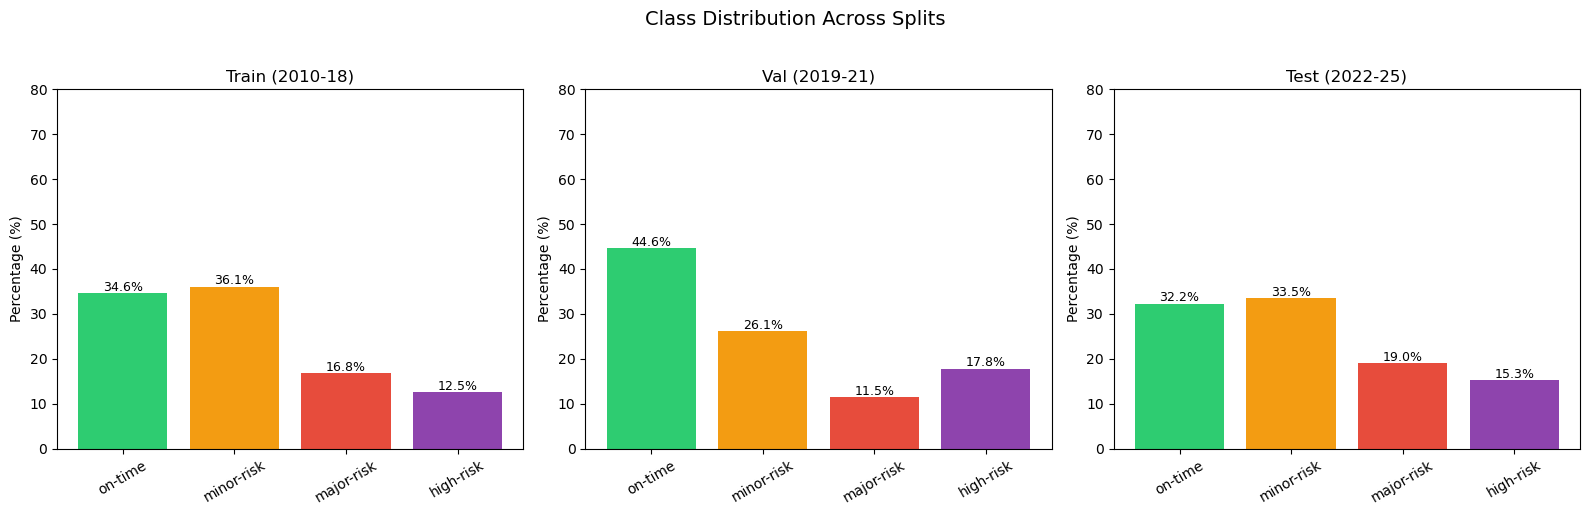


Class distributions:
  Train: on-time=48699(34.6%), minor-risk=50752(36.1%), major-risk=23644(16.8%), high-risk=17581(12.5%)
  Val: on-time=31369(44.6%), minor-risk=18363(26.1%), major-risk=8062(11.5%), high-risk=12532(17.8%)
  Test: on-time=22584(32.2%), minor-risk=23441(33.5%), major-risk=13299(19.0%), high-risk=10706(15.3%)


In [8]:
label_names = {0: 'on-time', 1: 'minor-risk', 2: 'major-risk', 3: 'high-risk'}
colors = ['#2ecc71', '#f39c12', '#e74c3c', '#8e44ad']

fig, axes = plt.subplots(1, 3, figsize=(16, 5))
for ax, (split_df, title) in zip(axes, [(train_df,'Train (2010-18)'), (val_df,'Val (2019-21)'), (test_df,'Test (2022-25)')]):
    counts = split_df[TARGET_COL].value_counts().sort_index()
    pcts = counts / len(split_df) * 100
    bars = ax.bar([label_names[i] for i in counts.index], pcts, color=colors)
    ax.set_title(title, fontsize=12)
    ax.set_ylabel('Percentage (%)')
    ax.set_ylim(0, 80)
    for bar, pct in zip(bars, pcts):
        ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.5, f'{pct:.1f}%', ha='center', fontsize=9)
    ax.tick_params(axis='x', rotation=30)

plt.suptitle('Class Distribution Across Splits', fontsize=14, y=1.02)
plt.tight_layout()
plt.savefig('class_distribution_splits.png', dpi=100, bbox_inches='tight')
plt.show()

print('\nClass distributions:')
for split_df, name in [(train_df,'Train'),(val_df,'Val'),(test_df,'Test')]:
    counts = split_df[TARGET_COL].value_counts().sort_index()
    print(f'  {name}: ' + ', '.join([f'{label_names[k]}={v}({v/len(split_df)*100:.1f}%)' for k,v in counts.items()]))

## 5. Class Weighting for Imbalanced Training

In [9]:
y_train = train_df[TARGET_COL].values
classes = np.unique(y_train)

class_weights = compute_class_weight(
    class_weight='balanced',
    classes=classes,
    y=y_train
)

class_weight_dict = dict(zip(classes.astype(int), class_weights))
print('Computed class weights (for sklearn models):')
for cls, weight in class_weight_dict.items():
    print(f'  Class {cls} ({label_names[cls]}): weight = {weight:.4f}')

# XGBoost uses scale_pos_weight — for multi-class use sample_weight
sample_weights_train = np.array([class_weight_dict[int(y)] for y in y_train])
print(f'\nSample weight range: [{sample_weights_train.min():.4f}, {sample_weights_train.max():.4f}]')
print('These weights will be used in NB04 for sklearn baselines.')

Computed class weights (for sklearn models):
  Class 0 (on-time): weight = 0.7222
  Class 1 (minor-risk): weight = 0.6930
  Class 2 (major-risk): weight = 1.4874
  Class 3 (high-risk): weight = 2.0004

Sample weight range: [0.6930, 2.0004]
These weights will be used in NB04 for sklearn baselines.


## 6. Save Splits to S3

In [10]:
def upload_split_to_s3(df_split, local_path, s3_key, bucket=PROCESSED_BUCKET):
    df_split.to_csv(local_path, index=False)
    try:
        s3_client.upload_file(local_path, bucket, s3_key)
        size_mb = os.path.getsize(local_path) / 1e6
        print(f'Uploaded s3://{bucket}/{s3_key} ({size_mb:.2f} MB, {len(df_split):,} rows)')
    except Exception as e:
        print(f'Upload note: {e}')

# Upload all three splits
upload_split_to_s3(train_df, '/tmp/train.csv', 'splits/train/train.csv')
upload_split_to_s3(val_df,   '/tmp/val.csv',   'splits/val/val.csv')
upload_split_to_s3(test_df,  '/tmp/test.csv',  'splits/test/test.csv')

print('\nS3 split paths:')
print(f'  Train: s3://{PROCESSED_BUCKET}/splits/train/train.csv')
print(f'  Val:   s3://{PROCESSED_BUCKET}/splits/val/val.csv')
print(f'  Test:  s3://{PROCESSED_BUCKET}/splits/test/test.csv')

Uploaded s3://skyaware-processed-data/splits/train/train.csv (50.49 MB, 140,676 rows)


Uploaded s3://skyaware-processed-data/splits/val/val.csv (23.78 MB, 70,326 rows)


Uploaded s3://skyaware-processed-data/splits/test/test.csv (24.49 MB, 70,030 rows)

S3 split paths:
  Train: s3://skyaware-processed-data/splits/train/train.csv
  Val:   s3://skyaware-processed-data/splits/val/val.csv
  Test:  s3://skyaware-processed-data/splits/test/test.csv


In [11]:
# XGBoost requires target as FIRST column, NO header
# Prepare XGB-format files for training jobs
def make_xgb_format(df_split, local_path, s3_key):
    feat_cols = [c for c in df_split.columns if c != TARGET_COL]
    xgb_df = pd.concat([df_split[[TARGET_COL]], df_split[feat_cols]], axis=1)
    xgb_df.to_csv(local_path, index=False, header=False)
    try:
        s3_client.upload_file(local_path, PROCESSED_BUCKET, s3_key)
        print(f'Uploaded XGB format: s3://{PROCESSED_BUCKET}/{s3_key}')
    except Exception as e:
        print(f'Upload note: {e}')

make_xgb_format(train_df, '/tmp/train_xgb.csv', 'splits/train/train_xgb.csv')
make_xgb_format(val_df,   '/tmp/val_xgb.csv',   'splits/val/val_xgb.csv')

Uploaded XGB format: s3://skyaware-processed-data/splits/train/train_xgb.csv


Uploaded XGB format: s3://skyaware-processed-data/splits/val/val_xgb.csv


## 7. Verify S3 Upload

In [12]:
try:
    response = s3_client.list_objects_v2(Bucket=PROCESSED_BUCKET, Prefix='splits/')
    print(f'Files in s3://{PROCESSED_BUCKET}/splits/:')
    for obj in response.get('Contents', []):
        size_kb = obj['Size'] / 1024
        print(f'  {obj["Key"]}  ({size_kb:.1f} KB)')
except Exception as e:
    print(f'List note: {e}')

Files in s3://skyaware-processed-data/splits/:
  splits/test/test.csv  (23919.1 KB)
  splits/test/test_features.csv  (23644.4 KB)
  splits/train/train.csv  (49305.0 KB)
  splits/train/train_xgb.csv  (49304.6 KB)
  splits/train/train_xgb_bias.csv  (49853.5 KB)
  splits/train/train_xgb_clarify.csv  (49303.5 KB)
  splits/val/val.csv  (23223.3 KB)
  splits/val/val_xgb.csv  (23222.8 KB)


## 8. Split Summary

Temporal split based on EDA findings: train on stable pre-COVID history, validate through the COVID disruption, test on post-pandemic recovery.

### Observed Results (Run: 2026-06-21)

#### Split Sizes & Class Distributions

| Split | Years | Rows | on-time | minor-risk | major-risk | high-risk | Notes |
|---|---|---|---|---|---|---|---|
| **Train** | 2010–2018 | 140,676 | 48,699 (34.6%) | 50,752 (36.1%) | 23,644 (16.8%) | 17,581 (12.5%) | Stable pre-COVID baseline |
| **Validation** | 2019–2021 | 70,326 | 31,369 (44.6%) | 18,363 (26.1%) | 8,062 (11.5%) | 12,532 (17.8%) | COVID anomaly: high on-time + elevated high-risk |
| **Test** | 2022–2025 | 70,030 | 22,584 (32.2%) | 23,441 (33.5%) | 13,299 (19.0%) | 10,706 (15.3%) | Post-pandemic recovery; 2025 partial year |

- Temporal assertion passed: **no data leakage** — year ranges strictly separated
- Final feature matrix: **30 features** + 1 target column = 31 columns per split

#### Categorical Encoders (fitted on Train only)

| Encoder | Classes | Unseen in Val | Unseen in Test |
|---|---|---|---|
| `carrier_enc` | 32 | 0 | 0 |
| `airport_enc` | 389 | 0 | 0 |

Both encoders saved to `s3://skyaware-processed-data/encoders/`.

#### Class Weights (for sklearn baselines in NB04)

| Class | Label | Weight |
|---|---|---|
| 0 | on-time | 0.7222 |
| 1 | minor-risk | 0.6930 |
| 2 | major-risk | 1.4874 |
| 3 | high-risk | 2.0004 |

Sample weight range: [0.6930, 2.0004]

#### S3 Upload Results

| File | Size | Rows |
|---|---|---|
| `splits/train/train.csv` | 50.49 MB | 140,676 |
| `splits/val/val.csv` | 23.78 MB | 70,326 |
| `splits/test/test.csv` | 24.49 MB | 70,030 |
| `splits/train/train_xgb.csv` | 49.30 MB | 140,676 |
| `splits/val/val_xgb.csv` | 23.22 MB | 70,326 |

S3 verification confirmed all 5 split files plus `test_features.csv` (used for batch inference in NB05/NB06).

---

**Observations:**
- Validation has an unusually **high on-time rate (44.6%)** and elevated high-risk (17.8%) — COVID 2020 had the lowest delay rate (9.3%) but spiked cancellations; `is_covid_period` flag captures this
- Test split closely mirrors overall EDA distribution — good signal that the model is evaluated on representative data
- Train high-risk is only 12.5% vs test 15.3% — slight upward trend in post-pandemic high-risk routes; class weighting in NB04 compensates

**Key design decisions:**
- **Temporal split only** — random split would leak future patterns into training (time-series data)
- **COVID years in validation** — model must generalise through anomalous periods, not avoid them
- `is_covid_period` flag lets the model learn COVID context rather than treating it as noise
- **`carrier_enc` / `airport_enc`** fitted on train only — 0 unseen labels in both val and test (confirmed)
- **XGBoost-format files** (no header, target column first) uploaded separately for the SageMaker built-in container
- **Class weighting** computed on train split — imbalance ratio 0.361 (high-risk : on-time in train), applied in NB04

In [13]:
print('=== FINAL SPLIT SUMMARY ===')
for split_df, name, yrs in [(train_df,'Train','2010-2018'),(val_df,'Val','2019-2021'),(test_df,'Test','2022-2025')]:
    counts = split_df[TARGET_COL].value_counts().sort_index()
    print(f'\n{name} ({yrs}): {len(split_df):,} rows')
    for k, v in counts.items():
        print(f'  Class {k} ({label_names[k]}): {v:,} ({v/len(split_df)*100:.1f}%)')

=== FINAL SPLIT SUMMARY ===

Train (2010-2018): 140,676 rows
  Class 0.0 (on-time): 48,699 (34.6%)
  Class 1.0 (minor-risk): 50,752 (36.1%)
  Class 2.0 (major-risk): 23,644 (16.8%)
  Class 3.0 (high-risk): 17,581 (12.5%)

Val (2019-2021): 70,326 rows
  Class 0.0 (on-time): 31,369 (44.6%)
  Class 1.0 (minor-risk): 18,363 (26.1%)
  Class 2.0 (major-risk): 8,062 (11.5%)
  Class 3.0 (high-risk): 12,532 (17.8%)

Test (2022-2025): 70,030 rows
  Class 0.0 (on-time): 22,584 (32.2%)
  Class 1.0 (minor-risk): 23,441 (33.5%)
  Class 2.0 (major-risk): 13,299 (19.0%)
  Class 3.0 (high-risk): 10,706 (15.3%)
